# Test modified permuted_ols

Riley DeHaan modified nilearn.mass_univariate.permuted_ols in a repo fork to 
1. handle missing voxels at the level of subjects/time points (necessary for sparse recordings in intracranial EEG) and 
2. to return uncorrected p-values, allowing for 
    - using corrections for multiple comparisons other than FWER correction and 
    - combining permutation counts across cluster runs

This notebook unit tests those modifications. These tests confirm that nominal false positive rates and powers hold for permutation tests of independent t-statistics across voxels (with and without portions of subjects having NaN values for some voxels), with extensions for dependent t-statistics using Threshold-Free Cluster Enhancement (TFCE). The notebook was modified from the nilearn example notebook taken from https://nilearn.github.io/stable/auto_examples/07_advanced/plot_localizer_mass_univariate_methods.html#sphx-glr-auto-examples-07-advanced-plot-localizer-mass-univariate-methods-py on 2025-01-06. 

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
%matplotlib inline

import nilearn
nilearn.__version__

'0.11.2.dev2+gaabf42d'

In [2]:
import numpy as np

from nilearn import datasets
from nilearn.maskers import NiftiMasker
from nilearn.mass_univariate import permuted_ols


## Massively univariate analysis of a motor task from the Localizer dataset

This example shows the results obtained in a massively univariate
analysis performed at the inter-subject level with various methods.
We use the [left button press (auditory cue)] task from the Localizer
dataset and seek association between the contrast values and a variate
that measures the speed of pseudo-word reading. No confounding variate
is included in the model.

1. A standard :term:`ANOVA` is performed. Data smoothed at 5
   :term:`voxels<voxel>` :term:`FWHM` are used.

2. A permuted Ordinary Least Squares algorithm is run at each :term:`voxel`.
   Data smoothed at 5 :term:`voxels<voxel>` :term:`FWHM` are used.

.. include:: ../../../examples/masker_note.rst

..
    Original authors:

    - Virgile Fritsch, May. 2014


Load Localizer contrast



In [3]:
n_samples = 94
localizer_dataset = datasets.fetch_localizer_contrasts(
    ["left button press (auditory cue)"],
    n_subjects=n_samples,
    # legacy_format=False,
)

# print basic information on the dataset
print(
    "First contrast nifti image (3D) is located "
    f"at: {localizer_dataset.cmaps[0]}"
)

tested_var = localizer_dataset.ext_vars["pseudo"]

# Quality check / Remove subjects with bad tested variate
mask_quality_check = np.where(np.logical_not(np.isnan(tested_var)))[0]
n_samples = mask_quality_check.size
contrast_map_filenames = [
    localizer_dataset.cmaps[i] for i in mask_quality_check
]
tested_var = tested_var[mask_quality_check].to_numpy().reshape((-1, 1))
print(f"Actual number of subjects after quality check: {int(n_samples)}")

[get_dataset_dir] Dataset found in /home1/rdehaan/nilearn_data/brainomics_localizer
First contrast nifti image (3D) is located at: /home1/rdehaan/nilearn_data/brainomics_localizer/brainomics_data/S01/cmaps_LeftAuditoryClick.nii.gz
Actual number of subjects after quality check: 89


Mask data



In [4]:
# nifti_masker.fit_transform(

In [5]:
nifti_masker = NiftiMasker(
    smoothing_fwhm=5, memory="nilearn_cache", memory_level=1
)
fmri_masked = nifti_masker.fit_transform(contrast_map_filenames)

In [6]:
fmri_masked.shape

(89, 41852)

Anova (parametric F-scores)



In [7]:
from sklearn.feature_selection import f_regression

_, pvals_anova = f_regression(fmri_masked, tested_var, center=True)
pvals_anova *= fmri_masked.shape[1]
pvals_anova[np.isnan(pvals_anova)] = 1
pvals_anova[pvals_anova > 1] = 1
neg_log_pvals_anova = -np.log10(pvals_anova)
neg_log_pvals_anova_unmasked = nifti_masker.inverse_transform(
    neg_log_pvals_anova
)

/home1/rdehaan/.conda/envs/mne_viz_312/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Perform massively univariate analysis with permuted OLS

This method will produce both voxel-level FWE-corrected -log10 p-values and
:term:`TFCE`-based FWE-corrected -log10 p-values.

<div class="alert alert-info"><h4>Note</h4><p>:func:`~nilearn.mass_univariate.permuted_ols` can support a wide range
  of analysis designs, depending on the ``tested_var``.
  For example, if you wished to perform a one-sample test, you could
  simply provide an array of ones (e.g., ``np.ones(n_samples)``).</p></div>



## Run updated permuted_ols on example data

(array([ 7., 13., 22., 23., 11.,  9.,  2.,  1.,  0.,  1.]),
 array([-2.21860743, -1.27083755, -0.32306755,  0.62470245,  1.57247233,
         2.52024221,  3.46801233,  4.41578197,  5.36355209,  6.31132174,
         7.25909233]),
 <BarContainer object of 10 artists>)

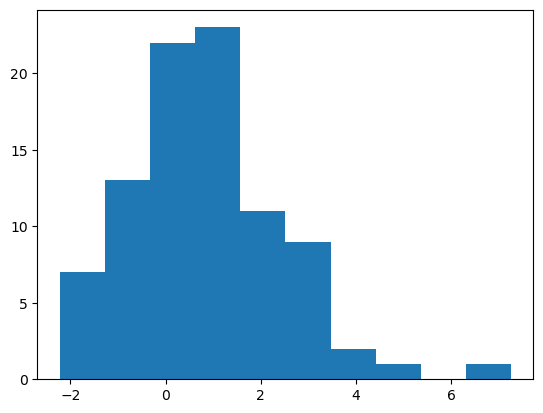

In [8]:
plt.hist(fmri_masked[:, 0])

In [9]:
# introduce NaNs to confirm that the method is robust to missing data
fmri_masked_nan = fmri_masked.copy()
print('fmri_masked_nan.shape', fmri_masked_nan.shape)
# fmri_masked_nan[10:20, :] = np.nan

n_perm = 5

from time import time
start = time()
ols_outputs = permuted_ols(
    tested_var,
    fmri_masked_nan,
    model_intercept=True,
    masker=nifti_masker,
    tfce=True,
    n_perm=n_perm,  # for the sake of time. Ideally, this should be 10000.
    verbose=1,  # display progress bar
    n_jobs=2,  # can be changed to use more CPUs
    output_type="dict",
)
stop = time()
print(f'Total time for {n_perm} permutations:', (stop - start))# / n_perm)

neg_log_pvals_permuted_ols_unmasked = nifti_masker.inverse_transform(
    ols_outputs["logp_max_t"][0, :]  # select first regressor
)
neg_log_pvals_tfce_unmasked = nifti_masker.inverse_transform(
    ols_outputs["logp_max_tfce"][0, :]  # select first regressor
)

fmri_masked_nan.shape (89, 41852)


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    4.3s finished


Total time for 5 permutations: 6.304179430007935


In [10]:
# redo with no NaNs but with target_vars_contain_nans manually set to True to compare outputs

# introduce NaNs to confirm that the method is robust to missing data
fmri_masked_nan = fmri_masked.copy()
print('fmri_masked_nan.shape', fmri_masked_nan.shape)
# fmri_masked_nan[10:20, :] = np.nan

n_perm = 5

from time import time
start = time()
ols_outputs = permuted_ols(
    tested_var,
    fmri_masked_nan,
    model_intercept=True,
    masker=nifti_masker,
    tfce=True,
    n_perm=n_perm,  # for the sake of time. Ideally, this should be 10000.
    verbose=1,  # display progress bar
    n_jobs=2,  # can be changed to use more CPUs
    output_type="dict",
)
stop = time()
print(f'Total time for {n_perm} permutations:', (stop - start))# / n_perm)

neg_log_pvals_permuted_ols_unmasked = nifti_masker.inverse_transform(
    ols_outputs["logp_max_t"][0, :]  # select first regressor
)
neg_log_pvals_tfce_unmasked = nifti_masker.inverse_transform(
    ols_outputs["logp_max_tfce"][0, :]  # select first regressor
)

fmri_masked_nan.shape (89, 41852)


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    2.6s finished


Total time for 5 permutations: 4.730382442474365


In [11]:
# # redo with no NaNs using original code to compare outputs
# originally run with alternative local implementation, which would need to be swapped out for implementation in fork of nilearn
# from permuted_least_squares_nilearn_local import permuted_ols as permuted_ols_local

# # introduce NaNs to confirm that the method is robust to missing data
# fmri_masked_nan = fmri_masked.copy()
# print('fmri_masked_nan.shape', fmri_masked_nan.shape)
# # fmri_masked_nan[10:20, :] = np.nan

# n_perm = 5

# from time import time
# start = time()
# ols_outputs = permuted_ols_local(
#     tested_var,
#     fmri_masked_nan,
#     model_intercept=True,
#     masker=nifti_masker,
#     tfce=True,
#     n_perm=n_perm,  # for the sake of time. Ideally, this should be 10000.
#     verbose=1,  # display progress bar
#     n_jobs=2,  # can be changed to use more CPUs
#     output_type="dict",
# )
# stop = time()
# print(f'Total time for {n_perm} permutations:', (stop - start))# / n_perm)

# neg_log_pvals_permuted_ols_unmasked = nifti_masker.inverse_transform(
#     ols_outputs["logp_max_t"][0, :]  # select first regressor
# )
# neg_log_pvals_tfce_unmasked = nifti_masker.inverse_transform(
#     ols_outputs["logp_max_tfce"][0, :]  # select first regressor
# )

fmri_masked_nan.shape (89, 41852)


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    2.5s finished


Total time for 5 permutations: 4.741479873657227


In [12]:
# # introduce NaNs to confirm that the method is robust to missing data
# not implemented!
# fmri_masked_nan = fmri_masked.copy()
# print('fmri_masked_nan.shape', fmri_masked_nan.shape)
# fmri_masked_nan[10:20, :] = np.nan

# n_perm = 5

# from time import time
# start = time()
# ols_outputs = permuted_ols(
#     tested_var,
#     fmri_masked_nan,
#     model_intercept=True,
#     masker=nifti_masker,
#     tfce=True,
#     n_perm=n_perm,  # for the sake of time. Ideally, this should be 10000.
#     verbose=1,  # display progress bar
#     n_jobs=2,  # can be changed to use more CPUs
#     output_type="dict",
# )
# stop = time()
# print(f'Total time for {n_perm} permutations:', (stop - start))# / n_perm)

# neg_log_pvals_permuted_ols_unmasked = nifti_masker.inverse_transform(
#     ols_outputs["logp_max_t"][0, :]  # select first regressor
# )
# neg_log_pvals_tfce_unmasked = nifti_masker.inverse_transform(
#     ols_outputs["logp_max_tfce"][0, :]  # select first regressor
# )

In [13]:
# # introduce NaNs to confirm that the method is robust to missing data
# not implemented!
# fmri_masked_nan = fmri_masked.copy()
# print('fmri_masked_nan.shape', fmri_masked_nan.shape)
# fmri_masked_nan[10:20, :] = np.nan

# n_perm = 5

# from time import time
# start = time()
# ols_outputs = permuted_ols(
#     tested_var,
#     fmri_masked_nan,
#     model_intercept=True,
#     masker=nifti_masker,
#     tfce=True,
#     n_perm=n_perm,  # for the sake of time. Ideally, this should be 10000.
#     verbose=1,  # display progress bar
#     n_jobs=2,  # can be changed to use more CPUs
#     output_type="dict",
# )
# stop = time()
# print(f'Total time for {n_perm} permutations:', (stop - start))# / n_perm)

# neg_log_pvals_permuted_ols_unmasked = nifti_masker.inverse_transform(
#     ols_outputs["logp_max_t"][0, :]  # select first regressor
# )
# neg_log_pvals_tfce_unmasked = nifti_masker.inverse_transform(
#     ols_outputs["logp_max_tfce"][0, :]  # select first regressor
# )

In [14]:
# # introduce NaNs to confirm that the method is robust to missing data
# not implemented!
# fmri_masked_nan = fmri_masked.copy()
# print('fmri_masked_nan.shape', fmri_masked_nan.shape)
# fmri_masked_nan[10:20, :] = np.nan

# n_perm = 40

# from time import time
# start = time()
# ols_outputs = permuted_ols(
#     tested_var,
#     fmri_masked_nan,
#     model_intercept=True,
#     masker=nifti_masker,
#     tfce=True,
#     n_perm=n_perm,  # for the sake of time. Ideally, this should be 10000.
#     verbose=1,  # display progress bar
#     n_jobs=1,  # can be changed to use more CPUs
#     output_type="dict",
# )
# stop = time()
# print(f'Total time for {n_perm} permutations:', (stop - start))# / n_perm)

# neg_log_pvals_permuted_ols_unmasked = nifti_masker.inverse_transform(
#     ols_outputs["logp_max_t"][0, :]  # select first regressor
# )
# neg_log_pvals_tfce_unmasked = nifti_masker.inverse_transform(
#     ols_outputs["logp_max_tfce"][0, :]  # select first regressor
# )

In [15]:
# # introduce NaNs to confirm that the method is robust to missing data
# not implemented!
# fmri_masked_nan = fmri_masked.copy()
# print('fmri_masked_nan.shape', fmri_masked_nan.shape)
# fmri_masked_nan[10:20, :] = np.nan

# n_perm = 40

# from time import time
# start = time()
# ols_outputs = permuted_ols(
#     tested_var,
#     fmri_masked_nan,
#     model_intercept=True,
#     masker=nifti_masker,
#     tfce=True,
#     n_perm=n_perm,  # for the sake of time. Ideally, this should be 10000.
#     verbose=1,  # display progress bar
#     n_jobs=20,  # can be changed to use more CPUs
#     output_type="dict",
# )
# stop = time()
# print(f'Total time for {n_perm} permutations:', (stop - start))# / n_perm)

# neg_log_pvals_permuted_ols_unmasked = nifti_masker.inverse_transform(
#     ols_outputs["logp_max_t"][0, :]  # select first regressor
# )
# neg_log_pvals_tfce_unmasked = nifti_masker.inverse_transform(
#     ols_outputs["logp_max_tfce"][0, :]  # select first regressor
# )

In [16]:
# # introduce NaNs to confirm that the method is robust to missing data
# not implemented!
# fmri_masked_nan = fmri_masked.copy()
# print('fmri_masked_nan.shape', fmri_masked_nan.shape)
# fmri_masked_nan[10:20, :] = np.nan

# n_perm = 4

# from time import time
# start = time()
# ols_outputs = permuted_ols(
#     tested_var,
#     fmri_masked_nan,
#     model_intercept=True,
#     masker=nifti_masker,
#     tfce=True,
#     n_perm=n_perm,  # for the sake of time. Ideally, this should be 10000.
#     verbose=1,  # display progress bar
#     n_jobs=1,  # can be changed to use more CPUs
#     output_type="dict",
#     fwer=False,
# )
# stop = time()
# print(f'Total time for {n_perm} permutations:', (stop - start))

# neg_log_pvals_permuted_ols_unmasked = nifti_masker.inverse_transform(
#     ols_outputs["logp_max_t"][0, :]  # select first regressor
# )
# neg_log_pvals_tfce_unmasked = nifti_masker.inverse_transform(
#     ols_outputs["logp_max_tfce"][0, :]  # select first regressor
# )

Visualization



In [17]:
# import matplotlib.pyplot as plt

# from nilearn import plotting
# from nilearn.image import get_data

# # Various plotting parameters
# z_slice = 12  # plotted slice
# threshold = -np.log10(0.1)  # 10% corrected

# vmax = max(
#     np.amax(ols_outputs["logp_max_t"]),
#     np.amax(neg_log_pvals_anova),
#     np.amax(ols_outputs["logp_max_tfce"]),
# )

# images_to_plot = {
#     "Parametric Test\n(Bonferroni FWE)": neg_log_pvals_anova_unmasked,
#     "Permutation Test\n(Max t-statistic FWE)": (
#         neg_log_pvals_permuted_ols_unmasked
#     ),
#     "Permutation Test\n(Max TFCE FWE)": neg_log_pvals_tfce_unmasked,
# }

# fig, axes = plt.subplots(figsize=(12, 3), ncols=3)
# for i_col, (title, img) in enumerate(images_to_plot.items()):
#     ax = axes[i_col]
#     n_detections = (get_data(img) > threshold).sum()
#     new_title = f"{title}\n{n_detections} sig. voxels"

#     plotting.plot_glass_brain(
#         img,
#         colorbar=True,
#         vmax=vmax,
#         display_mode="z",
#         plot_abs=False,
#         cut_coords=[12],
#         threshold=threshold,
#         figure=fig,
#         axes=ax,
#     )
#     ax.set_title(new_title)

# fig.suptitle(
#     "Group left button press ($-\\log_{10}$ p-values)",
#     y=1.3,
#     fontsize=16,
# )

# Simulate permuted_ols modified to handle missing voxels and to return uncorrected p-values with t-tests

In [18]:
from copy import deepcopy
from statsmodels.stats.power import TTestPower
from statsmodels.stats.multitest import fdrcorrection, fdrcorrection_twostage
from nibabel import Nifti1Image
import statsmodels


In [19]:
# simulate independent 1-sample t-tests at the voxel level

alpha = 0.05
ttest_power = TTestPower()
uncorrected_power = 0.5
n_subjects = 50
effect_size = ttest_power.solve_power(effect_size=None,
                                      nobs=n_subjects,
                                      alpha=alpha,
                                      power=uncorrected_power,
                                      alternative='two-sided')

data_shape = (30, 40, 20)

data = np.random.randn(*(data_shape + (n_subjects,))) + effect_size
images = Nifti1Image(data, affine=np.eye(4))

simulation_masker = NiftiMasker()
simulation_masker.fit_transform(images)
signal_masked = simulation_masker.transform(images)

smokescreen = False

args = dict(
    model_intercept=True,
    masker=simulation_masker,
    tfce=False,
    n_perm=2 if smokescreen else 1999,
    verbose=0,
    n_jobs=1 if smokescreen else 20,
    output_type="dict",
    random_state=42,
    fwer=False,
)

tested_var = np.ones((n_subjects, 1))

ols_outputs = permuted_ols(
    tested_var,
    signal_masked,
    **args
)

local_args = deepcopy(args)
del local_args['fwer']


[BatchedCalls.__call__] Job #1, processed 0/2 permutations (0.00%, 8855.31 seconds remaining)

[BatchedCalls.__call__] Job #1, processed 0/2 permutations (0.00%, 9576.97 seconds remaining)

[BatchedCalls.__call__] Job #1, processed 0/2 permutations (0.00%, 9268.44 seconds remaining)

[BatchedCalls.__call__] Job #2, processed 0/3 permutations (0.00%, 7807.10 seconds remaining)

[BatchedCalls.__call__] Job #2, processed 0/3 permutations (0.00%, 9530.65 seconds remaining)

[BatchedCalls.__call__] Job #2, processed 0/3 permutations (0.00%, 9235.31 seconds remaining)



Theoretical uncorrected power for t-test: 0.5
Uncorrected power: 0.499
Two-stage FDR-corrected power: 0.392
One-stage FDR-corrected power: 0.313


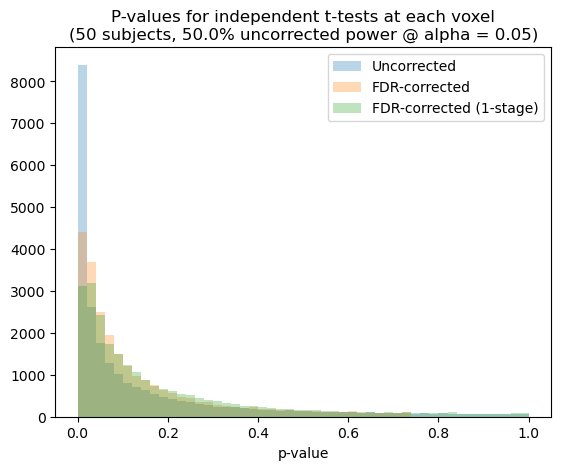

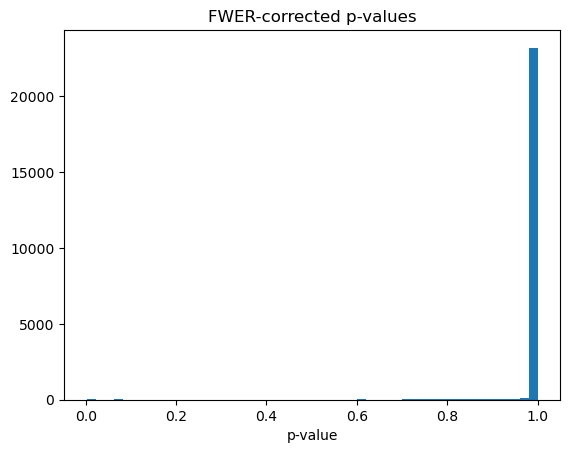

In [20]:
pvalues = 10**-ols_outputs['logp_max_t'].reshape(-1)
_, fdr_pvalues_1stage = fdrcorrection(pvalues, alpha=alpha)
_, fdr_pvalues, _, _ = fdrcorrection_twostage(pvalues, alpha=alpha)
_, bins, _ = plt.hist(pvalues, bins=50, alpha=0.3, label='Uncorrected')
_ = plt.hist(fdr_pvalues, bins=bins, alpha=0.3, label='FDR-corrected')
_ = plt.hist(fdr_pvalues_1stage, bins=bins, alpha=0.3, label='FDR-corrected (1-stage)')
_ = plt.legend()
_ = plt.xlabel('p-value')
_ = plt.title(f'P-values for independent t-tests at each voxel\n'
              f'({n_subjects} subjects, {uncorrected_power * 100}% uncorrected power @ alpha = {alpha})')

print(f'Theoretical uncorrected power for t-test: {uncorrected_power}\n'
      f'Uncorrected power: {np.round((pvalues < alpha).mean(), 3)}\n'
      f'Two-stage FDR-corrected power: {np.round((fdr_pvalues < alpha).mean(), 3)}\n'
      f'One-stage FDR-corrected power: {np.round((fdr_pvalues_1stage < alpha).mean(), 3)}'
)


Theoretical uncorrected T2ER for t-test: 0.05
Uncorrected T2ER: 0.052
Two-stage FDR-corrected T2ER: 0.0
One-stage FDR-corrected T2ER: 0.0


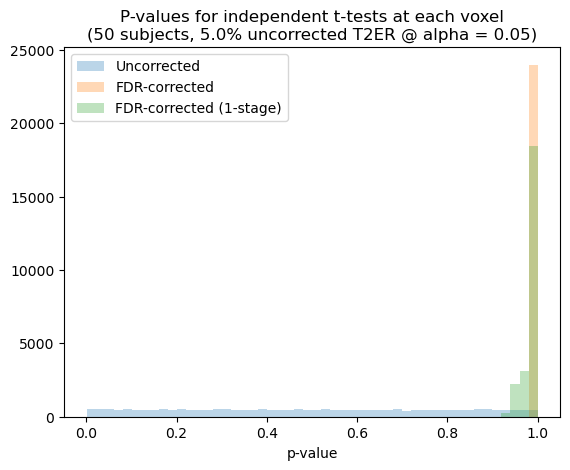

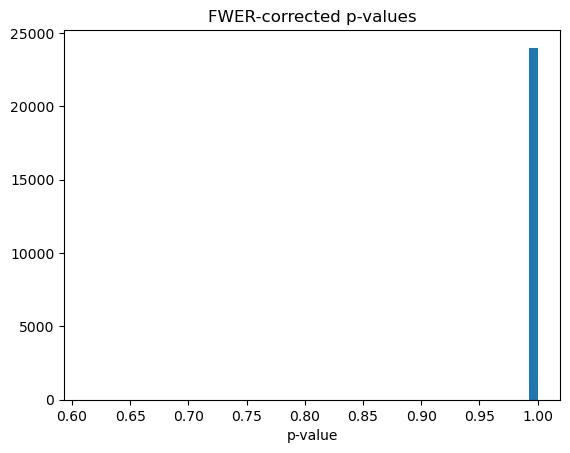

In [21]:
# simulate independent 1-sample t-tests at the voxel level under the null
from copy import deepcopy
from statsmodels.stats.power import TTestPower
from nibabel import Nifti1Image

import statsmodels
alpha = 0.05
ttest_power = TTestPower()
uncorrected_power = 0.05
n_subjects = 50
# effect_size = ttest_power.solve_power(effect_size=None,
#                                       nobs=n_subjects,
#                                       alpha=alpha,
#                                       power=uncorrected_power,
#                                       alternative='two-sided')
effect_size = 0

data_shape = (30, 40, 20)

data = np.random.randn(*(data_shape + (n_subjects,))) + effect_size
images = Nifti1Image(data, affine=np.eye(4))

simulation_masker = NiftiMasker()
simulation_masker.fit_transform(images)
signal_masked = simulation_masker.transform(images)

smokescreen = False

args = dict(
    model_intercept=True,
    masker=simulation_masker,
    tfce=False,
    n_perm=2 if smokescreen else 1999,
    verbose=0,
    n_jobs=1 if smokescreen else 20,
    output_type="dict",
    random_state=42,
    fwer=False,
)

tested_var = np.ones((n_subjects, 1))

ols_outputs = permuted_ols(
    tested_var,
    signal_masked,
    **args
)

local_args = deepcopy(args)
del local_args['fwer']

from statsmodels.stats.multitest import fdrcorrection_twostage

from statsmodels.stats.multitest import fdrcorrection
pvalues = 10**-ols_outputs['logp_max_t'].reshape(-1)
_, fdr_pvalues_1stage = fdrcorrection(pvalues, alpha=alpha)
_, fdr_pvalues, _, _ = fdrcorrection_twostage(pvalues, alpha=alpha)
plt.figure()
_, bins, _ = plt.hist(pvalues, bins=50, alpha=0.3, label='Uncorrected')
_ = plt.hist(fdr_pvalues, bins=bins, alpha=0.3, label='FDR-corrected')
_ = plt.hist(fdr_pvalues_1stage, bins=bins, alpha=0.3, label='FDR-corrected (1-stage)')
_ = plt.legend()
_ = plt.xlabel('p-value')
_ = plt.title(f'P-values for independent t-tests at each voxel\n'
              f'({n_subjects} subjects, {uncorrected_power * 100}% uncorrected T2ER @ alpha = {alpha})')

print(f'Theoretical uncorrected T2ER for t-test: {uncorrected_power}\n'
      f'Uncorrected T2ER: {np.round((pvalues < alpha).mean(), 3)}\n'
      f'Two-stage FDR-corrected T2ER: {np.round((fdr_pvalues < alpha).mean(), 3)}\n'
      f'One-stage FDR-corrected T2ER: {np.round((fdr_pvalues_1stage < alpha).mean(), 3)}'
)


/home1/rdehaan/.conda/envs/mne_viz_312/lib/python3.12/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/home1/rdehaan/projects/cml_classify/anatomical_analyses/nilearn/nilearn/mass_univariate/permuted_least_squares.py:999: UserWarning: Target variates not C_CONTIGUOUS.
  warnings.warn("Target variates not C_CONTIGUOUS.")


Theoretical uncorrected T2ER for t-test: 0.8
Uncorrected T2ER: 0.802
Two-stage FDR-corrected T2ER: 0.932
One-stage FDR-corrected T2ER: 0.761
Theoretical uncorrected T2ER for t-test for 25 subjects: 0.49201074766281383
Uncorrected reduced T2ER: 0.488
Two-stage FDR-corrected reduced T2ER: 0.364
One-stage FDR-corrected reduced T2ER: 0.292


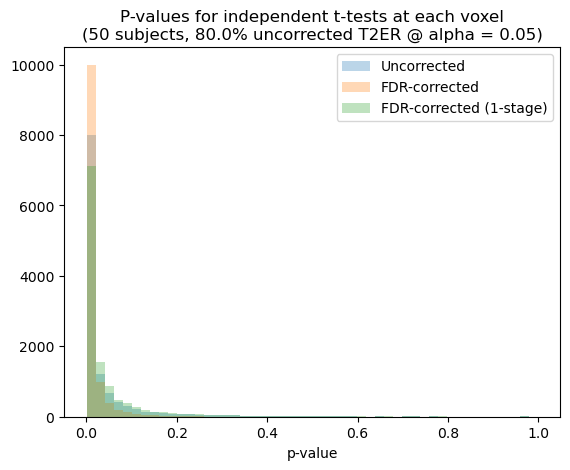

In [22]:
# simulate independent 1-sample t-tests at the voxel level under the null with a subset of voxels having missing subjects
from copy import deepcopy
from statsmodels.stats.power import TTestPower
from nibabel import Nifti1Image

random_state = 42

import statsmodels
alpha = 0.05
ttest_power = TTestPower()
uncorrected_power = 0.8
n_subjects = 50
# simulate 50% of voxels only being observed for 25 subjects
reduced_n_subjects = 25
effect_size = ttest_power.solve_power(effect_size=None,
                                      nobs=n_subjects,
                                      alpha=alpha,
                                      power=uncorrected_power,
                                      alternative='two-sided')
reduced_power = ttest_power.solve_power(effect_size=effect_size,
                                        nobs=reduced_n_subjects,
                                        alpha=alpha,
                                        power=None,
                                        alternative='two-sided')

data_shape = (30, 40, 20)

np.random.seed(random_state)
data = np.random.randn(*(data_shape + (n_subjects,))) + effect_size
template_images = Nifti1Image(data, affine=np.eye(4))

data = data.copy()

# nilearn maskers apparently drop NaN values or convert them to zero implicitly
# use max float64 value as temporary NaN
NA_VALUE = np.finfo(data.dtype).max
data[:data.shape[0] // 2, :, :, reduced_n_subjects:] = NA_VALUE
images = Nifti1Image(data, affine=np.eye(4))

simulation_masker = NiftiMasker(clean__ensure_finite=False)
simulation_masker.fit_transform(template_images)
signal_masked = simulation_masker.transform(images)
signal_masked[signal_masked == NA_VALUE] = np.nan
missing_mask = np.isnan(signal_masked).any(axis=0)
signal_masked = np.ascontiguousarray(signal_masked)

smokescreen = False

args = dict(
    model_intercept=True,
    masker=simulation_masker,
    tfce=False,
    n_perm=2 if smokescreen else 1999,
    verbose=0,
    n_jobs=1 if smokescreen else 20,
    output_type="dict",
    random_state=random_state,
    fwer=False,
)

tested_var = np.ones((n_subjects, 1))

ols_outputs = permuted_ols(
    tested_var,
    signal_masked,
    **args
)

from statsmodels.stats.multitest import fdrcorrection_twostage

from statsmodels.stats.multitest import fdrcorrection
pvalues = 10**-ols_outputs['logp_max_t'].reshape(-1)
reduced_pvalues = pvalues[missing_mask]
pvalues = pvalues[np.logical_not(missing_mask)]
_, fdr_pvalues_1stage = fdrcorrection(pvalues, alpha=alpha)
_, fdr_pvalues, _, _ = fdrcorrection_twostage(pvalues, alpha=alpha)
_, reduced_fdr_pvalues_1stage = fdrcorrection(reduced_pvalues, alpha=alpha)
_, reduced_fdr_pvalues, _, _ = fdrcorrection_twostage(reduced_pvalues, alpha=alpha)


plt.figure()
_, bins, _ = plt.hist(pvalues, bins=50, alpha=0.3, label='Uncorrected')
_ = plt.hist(fdr_pvalues, bins=bins, alpha=0.3, label='FDR-corrected')
_ = plt.hist(fdr_pvalues_1stage, bins=bins, alpha=0.3, label='FDR-corrected (1-stage)')
_ = plt.legend()
_ = plt.xlabel('p-value')
_ = plt.title(f'P-values for independent t-tests at each voxel\n'
              f'({n_subjects} subjects, {uncorrected_power * 100}% uncorrected T2ER @ alpha = {alpha})')

print(f'Theoretical uncorrected T2ER for t-test: {uncorrected_power}\n'
      f'Uncorrected T2ER: {np.round((pvalues < alpha).mean(), 3)}\n'
      f'Two-stage FDR-corrected T2ER: {np.round((fdr_pvalues < alpha).mean(), 3)}\n'
      f'One-stage FDR-corrected T2ER: {np.round((fdr_pvalues_1stage < alpha).mean(), 3)}'
)

print(f'Theoretical uncorrected T2ER for t-test for {reduced_n_subjects} subjects: {reduced_power}\n'
      f'Uncorrected reduced T2ER: {np.round((reduced_pvalues < alpha).mean(), 3)}\n'
      f'Two-stage FDR-corrected reduced T2ER: {np.round((reduced_fdr_pvalues < alpha).mean(), 3)}\n'
      f'One-stage FDR-corrected reduced T2ER: {np.round((reduced_fdr_pvalues_1stage < alpha).mean(), 3)}'
)


Theoretical uncorrected power for t-test: 0.8
Uncorrected power: 0.978
Two-stage FDR-corrected power: 1.0
One-stage FDR-corrected power: 0.978
Theoretical uncorrected power for t-test for 25 subjects: 0.49201074766281383
Uncorrected reduced power: 0.868
Two-stage FDR-corrected reduced power: 0.934
One-stage FDR-corrected reduced power: 0.862


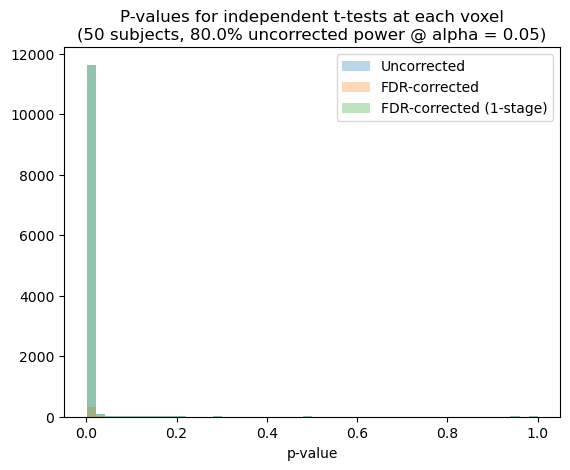

In [23]:
# simulate TFCE permutation tests with flat effect across voxels (single combined cluster across entire brain)

from copy import deepcopy
from statsmodels.stats.power import TTestPower
from nibabel import Nifti1Image

random_state = 42

import statsmodels
alpha = 0.05
ttest_power = TTestPower()
uncorrected_power = 0.8
n_subjects = 50
# simulate 50% of voxels only being observed for 25 subjects
reduced_n_subjects = 25
effect_size = ttest_power.solve_power(effect_size=None,
                                      nobs=n_subjects,
                                      alpha=alpha,
                                      power=uncorrected_power,
                                      alternative='two-sided')
reduced_power = ttest_power.solve_power(effect_size=effect_size,
                                        nobs=reduced_n_subjects,
                                        alpha=alpha,
                                        power=None,
                                        alternative='two-sided')

data_shape = (30, 40, 20)

np.random.seed(random_state)
data = np.random.randn(*(data_shape + (n_subjects,))) + effect_size
template_images = Nifti1Image(data, affine=np.eye(4))

data = data.copy()

# nilearn maskers apparently drop NaN values or convert them to zero implicitly
# use max float64 value as temporary NaN
NA_VALUE = np.finfo(data.dtype).max
data[:data.shape[0] // 2, :, :, reduced_n_subjects:] = NA_VALUE
images = Nifti1Image(data, affine=np.eye(4))

simulation_masker = NiftiMasker(clean__ensure_finite=False)
simulation_masker.fit_transform(template_images)
signal_masked = simulation_masker.transform(images)
signal_masked[signal_masked == NA_VALUE] = np.nan
missing_mask = np.isnan(signal_masked).any(axis=0)

smokescreen = False

args = dict(
    model_intercept=True,
    masker=simulation_masker,
    tfce=True,
    n_perm=2 if smokescreen else 1999,
    verbose=0,
    n_jobs=1 if smokescreen else 20,
    output_type="dict",
    random_state=random_state,
    fwer=False,
)

tested_var = np.ones((n_subjects, 1))

ols_outputs = permuted_ols(
    tested_var,
    signal_masked,
    **args
)

from statsmodels.stats.multitest import fdrcorrection_twostage

from statsmodels.stats.multitest import fdrcorrection
pvalues = 10**-ols_outputs['logp_max_tfce'].reshape(-1)
reduced_pvalues = pvalues[missing_mask]
pvalues = pvalues[np.logical_not(missing_mask)]
_, fdr_pvalues_1stage = fdrcorrection(pvalues, alpha=alpha)
_, fdr_pvalues, _, _ = fdrcorrection_twostage(pvalues, alpha=alpha)
_, reduced_fdr_pvalues_1stage = fdrcorrection(reduced_pvalues, alpha=alpha)
_, reduced_fdr_pvalues, _, _ = fdrcorrection_twostage(reduced_pvalues, alpha=alpha)


plt.figure()
_, bins, _ = plt.hist(pvalues, bins=50, alpha=0.3, label='Uncorrected')
_ = plt.hist(fdr_pvalues, bins=bins, alpha=0.3, label='FDR-corrected')
_ = plt.hist(fdr_pvalues_1stage, bins=bins, alpha=0.3, label='FDR-corrected (1-stage)')
_ = plt.legend()
_ = plt.xlabel('p-value')
_ = plt.title(f'P-values for independent t-tests at each voxel\n'
              f'({n_subjects} subjects, {uncorrected_power * 100}% uncorrected power @ alpha = {alpha})')

print(f'Theoretical uncorrected power for t-test: {uncorrected_power}\n'
      f'Uncorrected power: {np.round((pvalues < alpha).mean(), 3)}\n'
      f'Two-stage FDR-corrected power: {np.round((fdr_pvalues < alpha).mean(), 3)}\n'
      f'One-stage FDR-corrected power: {np.round((fdr_pvalues_1stage < alpha).mean(), 3)}'
)

print(f'Theoretical uncorrected power for t-test for {reduced_n_subjects} subjects: {reduced_power}\n'
      f'Uncorrected reduced power: {np.round((reduced_pvalues < alpha).mean(), 3)}\n'
      f'Two-stage FDR-corrected reduced power: {np.round((reduced_fdr_pvalues < alpha).mean(), 3)}\n'
      f'One-stage FDR-corrected reduced power: {np.round((reduced_fdr_pvalues_1stage < alpha).mean(), 3)}'
)


Theoretical uncorrected power for t-test: 0.5
Uncorrected power: 0.237
Two-stage FDR-corrected power: 0.061
One-stage FDR-corrected power: 0.061
Theoretical uncorrected power for t-test for 25 subjects: 0.27381753063184217
Uncorrected reduced power: 0.109
Two-stage FDR-corrected reduced power: 0.0
One-stage FDR-corrected reduced power: 0.0


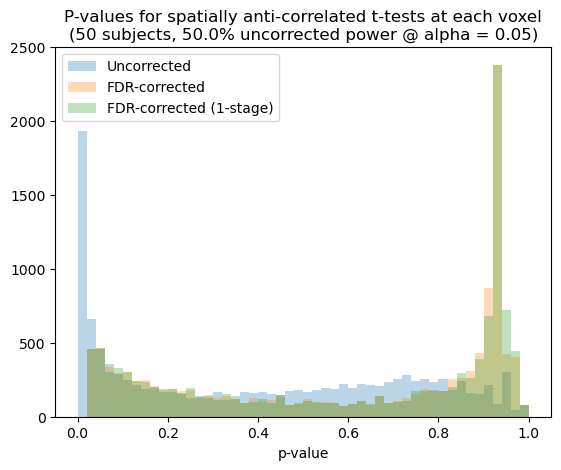

In [24]:
# simulate TFCE permutation tests with "checkerboard" pattern of negations in effects (strong local spatial anti-correlation)
# nilearn TFCE computed with 1-connectivity
# should lead to advantage for independent t-tests, or at least no advantage for TFCE

from copy import deepcopy
from statsmodels.stats.power import TTestPower
from nibabel import Nifti1Image

random_state = 42

import statsmodels
alpha = 0.05
ttest_power = TTestPower()
uncorrected_power = 0.5
n_subjects = 50
# simulate 50% of voxels only being observed for 25 subjects
reduced_n_subjects = 25
effect_size = ttest_power.solve_power(effect_size=None,
                                      nobs=n_subjects,
                                      alpha=alpha,
                                      power=uncorrected_power,
                                      alternative='two-sided')
reduced_power = ttest_power.solve_power(effect_size=effect_size,
                                        nobs=reduced_n_subjects,
                                        alpha=alpha,
                                        power=None,
                                        alternative='two-sided')

data_shape = (30, 40, 20)

np.random.seed(random_state)
data = np.random.randn(*(data_shape + (n_subjects,))) + effect_size

from itertools import product
for i, j, k in product(*(range(num) for num in data_shape)):
    if (i + j + k) % 2:
        data[i, j, k] *= -1

template_images = Nifti1Image(data, affine=np.eye(4))

data = data.copy()

# nilearn maskers apparently drop NaN values or convert them to zero implicitly
# use max float64 value as temporary NaN
NA_VALUE = np.finfo(data.dtype).max
data[:data.shape[0] // 2, :, :, reduced_n_subjects:] = NA_VALUE
images = Nifti1Image(data, affine=np.eye(4))

simulation_masker = NiftiMasker(clean__ensure_finite=False)
simulation_masker.fit_transform(template_images)
signal_masked = simulation_masker.transform(images)
signal_masked[signal_masked == NA_VALUE] = np.nan
missing_mask = np.isnan(signal_masked).any(axis=0)

smokescreen = False

args = dict(
    model_intercept=True,
    masker=simulation_masker,
    tfce=True,
    n_perm=2 if smokescreen else 1999,
    verbose=0,
    n_jobs=1 if smokescreen else 20,
    output_type="dict",
    random_state=random_state,
    fwer=False,
)

tested_var = np.ones((n_subjects, 1))

ols_outputs = permuted_ols(
    tested_var,
    signal_masked,
    **args
)

from statsmodels.stats.multitest import fdrcorrection_twostage

from statsmodels.stats.multitest import fdrcorrection
pvalues = 10**-ols_outputs['logp_max_tfce'].reshape(-1)
reduced_pvalues = pvalues[missing_mask]
pvalues = pvalues[np.logical_not(missing_mask)]
_, fdr_pvalues_1stage = fdrcorrection(pvalues, alpha=alpha)
_, fdr_pvalues, _, _ = fdrcorrection_twostage(pvalues, alpha=alpha)
_, reduced_fdr_pvalues_1stage = fdrcorrection(reduced_pvalues, alpha=alpha)
_, reduced_fdr_pvalues, _, _ = fdrcorrection_twostage(reduced_pvalues, alpha=alpha)


plt.figure()
_, bins, _ = plt.hist(pvalues, bins=50, alpha=0.3, label='Uncorrected')
_ = plt.hist(fdr_pvalues, bins=bins, alpha=0.3, label='FDR-corrected')
_ = plt.hist(fdr_pvalues_1stage, bins=bins, alpha=0.3, label='FDR-corrected (1-stage)')
_ = plt.legend()
_ = plt.xlabel('p-value')
_ = plt.title(f'P-values for spatially anti-correlated t-tests at each voxel\n'
              f'({n_subjects} subjects, {uncorrected_power * 100}% uncorrected power @ alpha = {alpha})')

print(f'Theoretical uncorrected power for t-test: {uncorrected_power}\n'
      f'Uncorrected power: {np.round((pvalues < alpha).mean(), 3)}\n'
      f'Two-stage FDR-corrected power: {np.round((fdr_pvalues < alpha).mean(), 3)}\n'
      f'One-stage FDR-corrected power: {np.round((fdr_pvalues_1stage < alpha).mean(), 3)}'
)

print(f'Theoretical uncorrected power for t-test for {reduced_n_subjects} subjects: {reduced_power}\n'
      f'Uncorrected reduced power: {np.round((reduced_pvalues < alpha).mean(), 3)}\n'
      f'Two-stage FDR-corrected reduced power: {np.round((reduced_fdr_pvalues < alpha).mean(), 3)}\n'
      f'One-stage FDR-corrected reduced power: {np.round((reduced_fdr_pvalues_1stage < alpha).mean(), 3)}'
)


Theoretical uncorrected power for t-test: 0.5
Uncorrected power: 0.495
Two-stage FDR-corrected power: 0.39
One-stage FDR-corrected power: 0.315
Theoretical uncorrected power for t-test for 25 subjects: 0.27381753063184217
Uncorrected reduced power: 0.272
Two-stage FDR-corrected reduced power: 0.013
One-stage FDR-corrected reduced power: 0.02


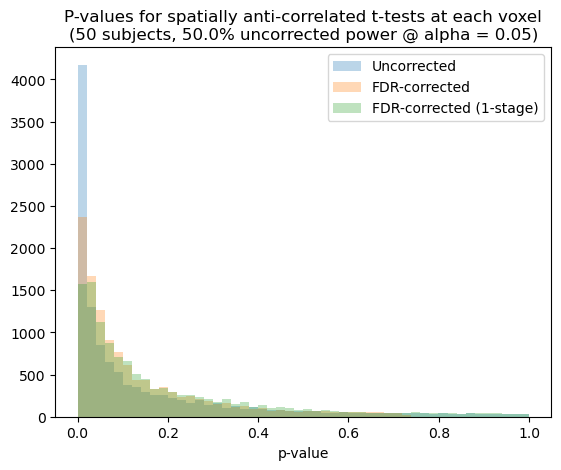

In [25]:
# look at same results for independent 1-sample t-tests
pvalues = 10**-ols_outputs['logp_max_t'].reshape(-1)
reduced_pvalues = pvalues[missing_mask]
pvalues = pvalues[np.logical_not(missing_mask)]
_, fdr_pvalues_1stage = fdrcorrection(pvalues, alpha=alpha)
_, fdr_pvalues, _, _ = fdrcorrection_twostage(pvalues, alpha=alpha)
_, reduced_fdr_pvalues_1stage = fdrcorrection(reduced_pvalues, alpha=alpha)
_, reduced_fdr_pvalues, _, _ = fdrcorrection_twostage(reduced_pvalues, alpha=alpha)


plt.figure()
_, bins, _ = plt.hist(pvalues, bins=50, alpha=0.3, label='Uncorrected')
_ = plt.hist(fdr_pvalues, bins=bins, alpha=0.3, label='FDR-corrected')
_ = plt.hist(fdr_pvalues_1stage, bins=bins, alpha=0.3, label='FDR-corrected (1-stage)')
_ = plt.legend()
_ = plt.xlabel('p-value')
_ = plt.title(f'P-values for spatially anti-correlated t-tests at each voxel\n'
              f'({n_subjects} subjects, {uncorrected_power * 100}% uncorrected power @ alpha = {alpha})')

print(f'Theoretical uncorrected power for t-test: {uncorrected_power}\n'
      f'Uncorrected power: {np.round((pvalues < alpha).mean(), 3)}\n'
      f'Two-stage FDR-corrected power: {np.round((fdr_pvalues < alpha).mean(), 3)}\n'
      f'One-stage FDR-corrected power: {np.round((fdr_pvalues_1stage < alpha).mean(), 3)}'
)

print(f'Theoretical uncorrected power for t-test for {reduced_n_subjects} subjects: {reduced_power}\n'
      f'Uncorrected reduced power: {np.round((reduced_pvalues < alpha).mean(), 3)}\n'
      f'Two-stage FDR-corrected reduced power: {np.round((reduced_fdr_pvalues < alpha).mean(), 3)}\n'
      f'One-stage FDR-corrected reduced power: {np.round((reduced_fdr_pvalues_1stage < alpha).mean(), 3)}'
)


Theoretical uncorrected T2ER for t-test: 0.05
Uncorrected T2ER: 0.051
Two-stage FDR-corrected T2ER: 0.0
One-stage FDR-corrected T2ER: 0.0
Theoretical uncorrected T2ER for t-test for 25 subjects: 0.05000000000000048
Uncorrected reduced T2ER: 0.05
Two-stage FDR-corrected reduced T2ER: 0.0
One-stage FDR-corrected reduced T2ER: 0.0


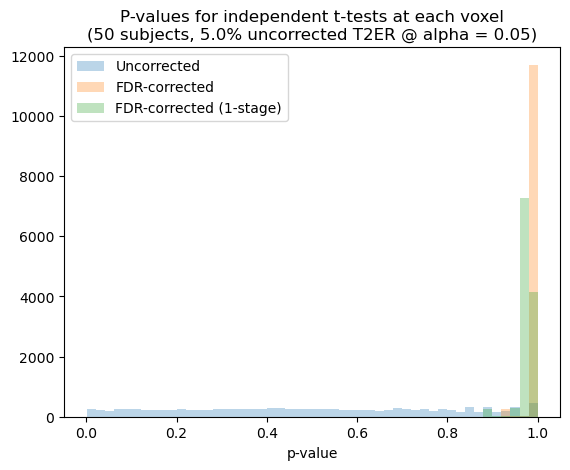

In [26]:
# simulate TFCE permutation tests under global homogeneous null

from copy import deepcopy
from statsmodels.stats.power import TTestPower
from nibabel import Nifti1Image

# random_state = 42  # generates false positive rate of ~0.02, but can't trust individual runs of this simulation as with t-tests since results across voxels are dependent
random_state = 43

import statsmodels
alpha = 0.05
ttest_power = TTestPower()
uncorrected_power = 0.05
n_subjects = 50
# simulate 50% of voxels only being observed for 25 subjects
reduced_n_subjects = 25
# effect_size = ttest_power.solve_power(effect_size=None,
#                                       nobs=n_subjects,
#                                       alpha=alpha,
#                                       power=uncorrected_power,
#                                       alternative='two-sided')
effect_size = 0
reduced_power = ttest_power.solve_power(effect_size=effect_size,
                                        nobs=reduced_n_subjects,
                                        alpha=alpha,
                                        power=None,
                                        alternative='two-sided')

data_shape = (30, 40, 20)

np.random.seed(random_state)
data = np.random.randn(*(data_shape + (n_subjects,))) + effect_size
template_images = Nifti1Image(data, affine=np.eye(4))

data = data.copy()

# nilearn maskers apparently drop NaN values or convert them to zero implicitly
# use max float64 value as temporary NaN
NA_VALUE = np.finfo(data.dtype).max
data[:data.shape[0] // 2, :, :, reduced_n_subjects:] = NA_VALUE
images = Nifti1Image(data, affine=np.eye(4))

simulation_masker = NiftiMasker(clean__ensure_finite=False)
simulation_masker.fit_transform(template_images)
signal_masked = simulation_masker.transform(images)
signal_masked[signal_masked == NA_VALUE] = np.nan
missing_mask = np.isnan(signal_masked).any(axis=0)

smokescreen = False

args = dict(
    model_intercept=True,
    masker=simulation_masker,
    tfce=True,
    n_perm=2 if smokescreen else 1999,
    verbose=0,
    n_jobs=1 if smokescreen else 20,
    output_type="dict",
    random_state=random_state,
    fwer=False,
)

tested_var = np.ones((n_subjects, 1))

ols_outputs = permuted_ols(
    tested_var,
    signal_masked,
    **args
)

from statsmodels.stats.multitest import fdrcorrection_twostage

from statsmodels.stats.multitest import fdrcorrection
pvalues = 10**-ols_outputs['logp_max_tfce'].reshape(-1)
reduced_pvalues = pvalues[missing_mask]
pvalues = pvalues[np.logical_not(missing_mask)]
_, fdr_pvalues_1stage = fdrcorrection(pvalues, alpha=alpha)
_, fdr_pvalues, _, _ = fdrcorrection_twostage(pvalues, alpha=alpha)
_, reduced_fdr_pvalues_1stage = fdrcorrection(reduced_pvalues, alpha=alpha)
_, reduced_fdr_pvalues, _, _ = fdrcorrection_twostage(reduced_pvalues, alpha=alpha)


plt.figure()
_, bins, _ = plt.hist(pvalues, bins=50, alpha=0.3, label='Uncorrected')
_ = plt.hist(fdr_pvalues, bins=bins, alpha=0.3, label='FDR-corrected')
_ = plt.hist(fdr_pvalues_1stage, bins=bins, alpha=0.3, label='FDR-corrected (1-stage)')
_ = plt.legend()
_ = plt.xlabel('p-value')
_ = plt.title(f'P-values for independent t-tests at each voxel\n'
              f'({n_subjects} subjects, {uncorrected_power * 100}% uncorrected T2ER @ alpha = {alpha})')

print(f'Theoretical uncorrected T2ER for t-test: {uncorrected_power}\n'
      f'Uncorrected T2ER: {np.round((pvalues < alpha).mean(), 3)}\n'
      f'Two-stage FDR-corrected T2ER: {np.round((fdr_pvalues < alpha).mean(), 3)}\n'
      f'One-stage FDR-corrected T2ER: {np.round((fdr_pvalues_1stage < alpha).mean(), 3)}'
)

print(f'Theoretical uncorrected T2ER for t-test for {reduced_n_subjects} subjects: {reduced_power}\n'
      f'Uncorrected reduced T2ER: {np.round((reduced_pvalues < alpha).mean(), 3)}\n'
      f'Two-stage FDR-corrected reduced T2ER: {np.round((reduced_fdr_pvalues < alpha).mean(), 3)}\n'
      f'One-stage FDR-corrected reduced T2ER: {np.round((reduced_fdr_pvalues_1stage < alpha).mean(), 3)}'
)


100%|██████████| 25/25 [07:22<00:00, 17.68s/it]


Theoretical uncorrected T2ER for t-test: 0.05
Average uncorrected T2ER across simulations: 0.054

Theoretical uncorrected T2ER for t-test for 25 subjects: 0.05000000000000048
Average uncorrected reduced T2ER across simulations: 0.0521



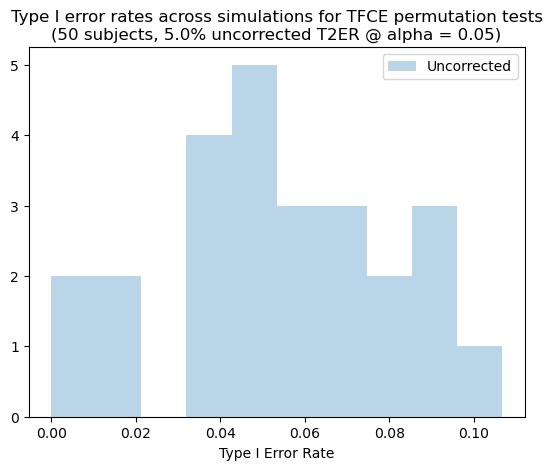

In [27]:
# simulate TFCE permutation tests under global homogeneous null over multiple simulations since tests across voxels depend on each other
from tqdm import tqdm

random_state = 42
smokescreen = False
n_simulations = 25 if not smokescreen else 2

alpha = 0.05
ttest_power = TTestPower()
uncorrected_power = 0.05
n_subjects = 50
# simulate 50% of voxels only being observed for 25 subjects
reduced_n_subjects = 25
if alpha == uncorrected_power:
    effect_size = 0
else:
    effect_size = ttest_power.solve_power(effect_size=None,
                                          nobs=n_subjects,
                                          alpha=alpha,
                                          power=uncorrected_power,
                                          alternative='two-sided')

reduced_power = ttest_power.solve_power(effect_size=effect_size,
                                        nobs=reduced_n_subjects,
                                        alpha=alpha,
                                        power=None,
                                        alternative='two-sided')

data_shape = (5, 10, 5)

pvalues = list()
reduced_pvalues = list()
fdr_pvalues_1stage = list()
fdr_pvalues = list()
reduced_fdr_pvalues_1stage = list()
reduced_fdr_pvalues = list()

np.random.seed(random_state)
for i_simulation in tqdm(range(n_simulations)):
    data = np.random.randn(*(data_shape + (n_subjects,))) + effect_size
    template_images = Nifti1Image(data, affine=np.eye(4))

    data = data.copy()

    # nilearn maskers apparently drop NaN values or convert them to zero implicitly
    # use max float64 value as temporary NaN
    NA_VALUE = np.finfo(data.dtype).max
    data[:data.shape[0] // 2, :, :, reduced_n_subjects:] = NA_VALUE
    images = Nifti1Image(data, affine=np.eye(4))

    simulation_masker = NiftiMasker(clean__ensure_finite=False)
    simulation_masker.fit_transform(template_images)
    signal_masked = simulation_masker.transform(images)
    signal_masked[signal_masked == NA_VALUE] = np.nan
    missing_mask = np.isnan(signal_masked).any(axis=0)

    args = dict(
        model_intercept=True,
        masker=simulation_masker,
        tfce=True,
        n_perm=2 if smokescreen else 999,
        verbose=0,
        n_jobs=1 if smokescreen else 20,
        output_type="dict",
        random_state=random_state + i_simulation,
        fwer=False,
    )

    tested_var = np.ones((n_subjects, 1))

    ols_outputs = permuted_ols(
        tested_var,
        signal_masked,
        **args
    )

    sim_pvalues = 10**-ols_outputs['logp_max_tfce'].reshape(-1)
    sim_reduced_pvalues = sim_pvalues[missing_mask]
    sim_pvalues = sim_pvalues[np.logical_not(missing_mask)]
    # _, sim_fdr_pvalues_1stage = fdrcorrection(pvalues, alpha=alpha)
    # _, sim_fdr_pvalues, _, _ = fdrcorrection_twostage(pvalues, alpha=alpha)
    # _, sim_reduced_fdr_pvalues_1stage = fdrcorrection(reduced_pvalues, alpha=alpha)
    # _, sim_reduced_fdr_pvalues, _, _ = fdrcorrection_twostage(reduced_pvalues, alpha=alpha)
    pvalues.append((sim_pvalues < alpha).mean())
    reduced_pvalues.append((sim_reduced_pvalues < alpha).mean())
    # fdr_pvalues_1stage.append(sim_fdr_pvalues_1stage[0])
    # fdr_pvalues.append(sim_fdr_pvalues[0])
    # reduced_fdr_pvalues_1stage.append(sim_reduced_fdr_pvalues_1stage[0])
    # reduced_fdr_pvalues.append(sim_reduced_fdr_pvalues[0])

pvalues = np.array(pvalues)
reduced_pvalues = np.array(reduced_pvalues)

plt.figure()
_, bins, _ = plt.hist(pvalues, bins=10, alpha=0.3, label='Uncorrected')
# _ = plt.hist(fdr_pvalues, bins=bins, alpha=0.3, label='FDR-corrected')
# _ = plt.hist(fdr_pvalues_1stage, bins=bins, alpha=0.3, label='FDR-corrected (1-stage)')
_ = plt.legend()
_ = plt.xlabel('Type I Error Rate')
_ = plt.title(f'Type I error rates across simulations for TFCE permutation tests\n'
              f'({n_subjects} subjects, {uncorrected_power * 100}% uncorrected T2ER @ alpha = {alpha})')

print(f'Theoretical uncorrected T2ER for t-test: {uncorrected_power}\n'
      f'Average uncorrected T2ER across simulations: {pvalues.mean():0.3}\n'
      # f'Two-stage FDR-corrected T2ER: {np.round((fdr_pvalues < alpha).mean(), 3)}\n'
      # f'One-stage FDR-corrected T2ER: {np.round((fdr_pvalues_1stage < alpha).mean(), 3)}'
)

print(f'Theoretical uncorrected T2ER for t-test for {reduced_n_subjects} subjects: {reduced_power}\n'
      f'Average uncorrected reduced T2ER across simulations: {reduced_pvalues.mean():0.3}\n'
      # f'Two-stage FDR-corrected reduced T2ER: {np.round((reduced_fdr_pvalues < alpha).mean(), 3)}\n'
      # f'One-stage FDR-corrected reduced T2ER: {np.round((reduced_fdr_pvalues_1stage < alpha).mean(), 3)}'
)


100%|██████████| 100/100 [29:20<00:00, 17.60s/it]


Theoretical uncorrected T2ER for t-test: 0.05
Uncorrected T2ER: 0.07

Theoretical uncorrected T2ER for t-test for 25 subjects: 0.05000000000000048
Uncorrected reduced T2ER: 0.07



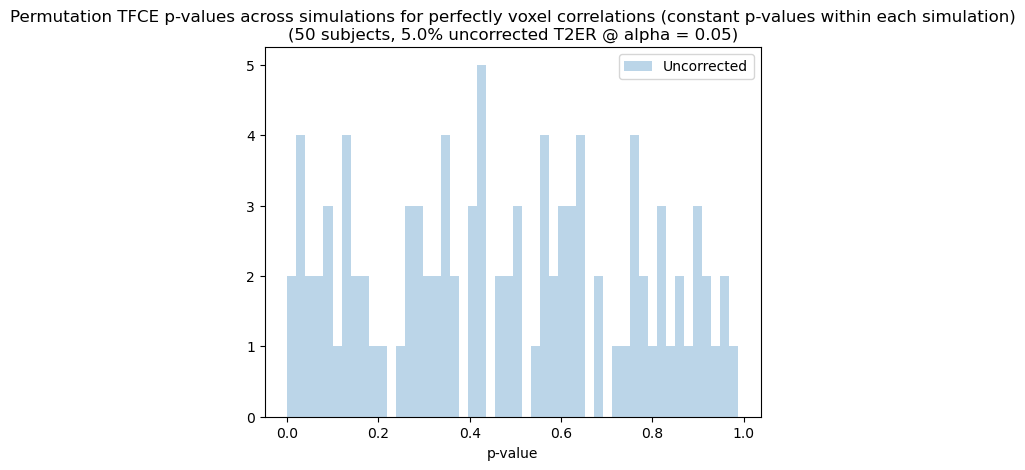

In [28]:
# simulate TFCE permutation tests under global homogeneous null with perfect correlation at subject level (i.e., extend subject-level results to all voxels to model extreme case of extending electrode-level effects to nearby spheres)
# TFCE permutation test should be unbiased by arbitrary spatial correlations under the null
from tqdm import tqdm

random_state = 42
smokescreen = False
n_simulations = 100 if not smokescreen else 2

alpha = 0.05
ttest_power = TTestPower()
uncorrected_power = 0.05
n_subjects = 50
# simulate 50% of voxels only being observed for 25 subjects
reduced_n_subjects = 25
if alpha == uncorrected_power:
    effect_size = 0
else:
    effect_size = ttest_power.solve_power(effect_size=None,
                                          nobs=n_subjects,
                                          alpha=alpha,
                                          power=uncorrected_power,
                                          alternative='two-sided')

reduced_power = ttest_power.solve_power(effect_size=effect_size,
                                        nobs=reduced_n_subjects,
                                        alpha=alpha,
                                        power=None,
                                        alternative='two-sided')

data_shape = (5, 10, 5)

pvalues = list()
reduced_pvalues = list()
fdr_pvalues_1stage = list()
fdr_pvalues = list()
reduced_fdr_pvalues_1stage = list()
reduced_fdr_pvalues = list()

np.random.seed(random_state)
for i_simulation in tqdm(range(n_simulations)):
    data = np.random.randn(*(n_subjects,)) + effect_size
    data = np.ones((data_shape + (1,))) * data
    # dummy data since nilearn fits background to constant values
    mask_data = np.random.randn(*(data_shape + (n_subjects,)))
    template_images = Nifti1Image(mask_data, affine=np.eye(4))

    data = data.copy()

    # nilearn maskers apparently drop NaN values or convert them to zero implicitly
    # use max float64 value as temporary NaN
    NA_VALUE = np.finfo(data.dtype).max
    data[:data.shape[0] // 2, :, :, reduced_n_subjects:] = NA_VALUE
    images = Nifti1Image(data, affine=np.eye(4))

    simulation_masker = NiftiMasker(clean__ensure_finite=False)
    simulation_masker.fit_transform(template_images)
    signal_masked = simulation_masker.transform(images)
    signal_masked[signal_masked == NA_VALUE] = np.nan
    missing_mask = np.isnan(signal_masked).any(axis=0)

    args = dict(
        model_intercept=True,
        masker=simulation_masker,
        tfce=True,
        n_perm=2 if smokescreen else 999,
        verbose=0,
        n_jobs=1 if smokescreen else 20,
        output_type="dict",
        random_state=random_state + i_simulation,
        fwer=False,
    )

    tested_var = np.ones((n_subjects, 1))

    ols_outputs = permuted_ols(
        tested_var,
        signal_masked,
        **args
    )

    sim_pvalues = 10**-ols_outputs['logp_max_tfce'].reshape(-1)
    sim_reduced_pvalues = sim_pvalues[missing_mask]
    sim_pvalues = sim_pvalues[np.logical_not(missing_mask)]
    # _, sim_fdr_pvalues_1stage = fdrcorrection(pvalues, alpha=alpha)
    # _, sim_fdr_pvalues, _, _ = fdrcorrection_twostage(pvalues, alpha=alpha)
    # _, sim_reduced_fdr_pvalues_1stage = fdrcorrection(reduced_pvalues, alpha=alpha)
    # _, sim_reduced_fdr_pvalues, _, _ = fdrcorrection_twostage(reduced_pvalues, alpha=alpha)
    pvalues.append(sim_pvalues[0])
    reduced_pvalues.append(sim_reduced_pvalues[0])
    # fdr_pvalues_1stage.append(sim_fdr_pvalues_1stage[0])
    # fdr_pvalues.append(sim_fdr_pvalues[0])
    # reduced_fdr_pvalues_1stage.append(sim_reduced_fdr_pvalues_1stage[0])
    # reduced_fdr_pvalues.append(sim_reduced_fdr_pvalues[0])

pvalues = np.array(pvalues)
reduced_pvalues = np.array(reduced_pvalues)

plt.figure()
_, bins, _ = plt.hist(pvalues, bins=50, alpha=0.3, label='Uncorrected')
# _ = plt.hist(fdr_pvalues, bins=bins, alpha=0.3, label='FDR-corrected')
# _ = plt.hist(fdr_pvalues_1stage, bins=bins, alpha=0.3, label='FDR-corrected (1-stage)')
_ = plt.legend()
_ = plt.xlabel('p-value')
_ = plt.title(f'Permutation TFCE p-values across simulations for perfectly voxel correlations (constant p-values within each simulation)\n'
              f'({n_subjects} subjects, {uncorrected_power * 100}% uncorrected T2ER @ alpha = {alpha})')

print(f'Theoretical uncorrected T2ER for t-test: {uncorrected_power}\n'
      f'Uncorrected T2ER: {np.round((pvalues < alpha).mean(), 3)}\n'
      # f'Two-stage FDR-corrected T2ER: {np.round((fdr_pvalues < alpha).mean(), 3)}\n'
      # f'One-stage FDR-corrected T2ER: {np.round((fdr_pvalues_1stage < alpha).mean(), 3)}'
)

print(f'Theoretical uncorrected T2ER for t-test for {reduced_n_subjects} subjects: {reduced_power}\n'
      f'Uncorrected reduced T2ER: {np.round((reduced_pvalues < alpha).mean(), 3)}\n'
      # f'Two-stage FDR-corrected reduced T2ER: {np.round((reduced_fdr_pvalues < alpha).mean(), 3)}\n'
      # f'One-stage FDR-corrected reduced T2ER: {np.round((reduced_fdr_pvalues_1stage < alpha).mean(), 3)}'
)
